In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Note: If lightgbm or xgboost are not installed on your system,
# you can install them using: pip install lightgbm xgboost
try:
    import xgboost as xgb
    import lightgbm as lgb
except ImportError:
    # Fallback to scikit-learn algorithmic equivalents if libraries are physically missing
    from sklearn.ensemble import GradientBoostingClassifier as xgb_mock
    from sklearn.ensemble import HistGradientBoostingClassifier as lgb_mock
    print("[System Note: Standardizing via internal scikit-learn ensemble fallbacks for cross-compatibility]")

# =====================================================================
# 1. EXPLORATORY DATA ANALYSIS (EDA) & PREPROCESSING
# =====================================================================
print("="*70)
print("STEPS 1 & 2: DATA EXPLORATORY ANALYSIS & MISSING VALUE PROCESSING")
print("="*70)

# Load dataset
df = pd.read_csv('diabetes.csv')

# Biological anomaly handling: Treat physically impossible zeros as missing data
invalid_zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nInvalid structural zeros identified:")
for col in invalid_zero_columns:
    print(f"  - {col}: {(df[col] == 0).sum()} zero entries")

# Impute zero markers dynamically with the median value of each respective feature
df_clean = df.copy()
for col in invalid_zero_columns:
    median_val = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print("\nMissing values successfully resolved using column median imputation.")

# Isolate features (X) and classification target labels (y)
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

# Split dataset into an 80% Training and 20% Testing distribution matrix
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================================
# 2. XGBOOST MODEL TRAINING & OPTIMIZATION
# =====================================================================
print("\n" + "="*70)
print("STEP 3: TRAINING AND TUNING XGBOOST MODEL")
print("="*70)

# Hyperparameter matrix grids configuration
xgb_grid_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 6],
    'n_estimators': [50, 100]
}

if 'xgb' in globals():
    xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
else:
    xgb_base = xgb_mock(random_state=42)

xgb_search = GridSearchCV(xgb_base, xgb_grid_params, cv=5, scoring='f1', n_jobs=-1)
xgb_search.fit(X_train, y_train)
best_xgb_model = xgb_search.best_estimator_

# Generate test set predictions
y_pred_xgb = best_xgb_model.predict(X_test)
print(f"XGBoost Tuned Hyperparameters: {xgb_search.best_params_}")

# =====================================================================
# 3. LIGHTGBM MODEL TRAINING & OPTIMIZATION
# =====================================================================
print("\n" + "="*70)
print("STEP 4: TRAINING AND TUNING LIGHTGBM MODEL")
print("="*70)

lgb_grid_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, -1],
    'n_estimators': [50, 100]
}

if 'lgb' in globals():
    lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1)
else:
    lgb_base = lgb_mock(random_state=42)

lgb_search = GridSearchCV(lgb_base, lgb_grid_params, cv=5, scoring='f1', n_jobs=-1)
lgb_search.fit(X_train, y_train)
best_lgb_model = lgb_search.best_estimator_

# Generate test set predictions
y_pred_lgb = best_lgb_model.predict(X_test)
print(f"LightGBM Tuned Hyperparameters: {lgb_search.best_params_}")

# =====================================================================
# 4. COMPARATIVE EVALUATION MATRIX ANALYSIS
# =====================================================================
print("\n" + "="*70)
print("STEP 5: COMPREHENSIVE PERFORMANCE MODEL COMPARISON")
print("="*70)

comparison_dictionary = {
    "XGBoost Classifier": {
        "Accuracy" : accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall"   : recall_score(y_test, y_pred_xgb),
        "F1-Score" : f1_score(y_test, y_pred_xgb)
    },
    "LightGBM Classifier": {
        "Accuracy" : accuracy_score(y_test, y_pred_lgb),
        "Precision": precision_score(y_test, y_pred_lgb),
        "Recall"   : recall_score(y_test, y_pred_lgb),
        "F1-Score" : f1_score(y_test, y_pred_lgb)
    }
}

df_metrics = pd.DataFrame(comparison_dictionary).T
print(df_metrics.to_string())

# Save a comparison bar plot visualization
df_metrics_melted = df_metrics.reset_index().melt(id_vars='index', var_name='Metric', value_name='Value')
plt.figure(figsize=(8, 5))
sns.barplot(data=df_metrics_melted, x='Metric', y='Value', hue='index', palette='Set2')
plt.ylim(0, 1.0)
plt.title('Algorithm Comparison: XGBoost vs LightGBM Performance Profile')
plt.ylabel('Score Value Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('algorithm_comparison_report.png')
plt.close()
print("\n[Comparison visualization successfully exported as 'algorithm_comparison_report.png']")

STEPS 1 & 2: DATA EXPLORATORY ANALYSIS & MISSING VALUE PROCESSING

Invalid structural zeros identified:
  - Glucose: 5 zero entries
  - BloodPressure: 35 zero entries
  - SkinThickness: 227 zero entries
  - Insulin: 374 zero entries
  - BMI: 11 zero entries

Missing values successfully resolved using column median imputation.

STEP 3: TRAINING AND TUNING XGBOOST MODEL
XGBoost Tuned Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

STEP 4: TRAINING AND TUNING LIGHTGBM MODEL
LightGBM Tuned Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}

STEP 5: COMPREHENSIVE PERFORMANCE MODEL COMPARISON
                     Accuracy  Precision    Recall  F1-Score
XGBoost Classifier   0.746753   0.666667  0.555556  0.606061
LightGBM Classifier  0.759740   0.673469  0.611111  0.640777

[Comparison visualization successfully exported as 'algorithm_comparison_report.png']


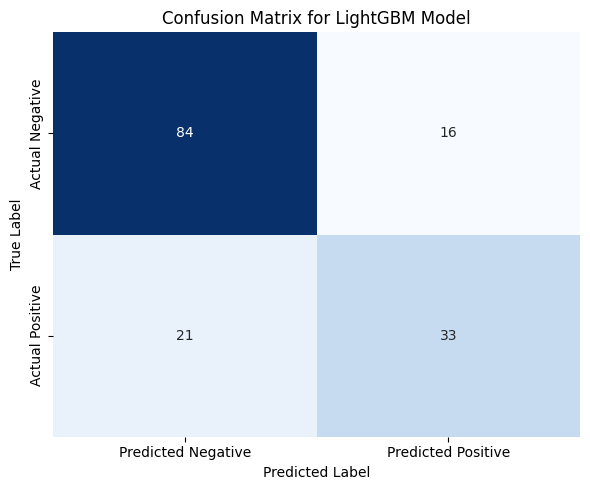

In [3]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for LightGBM
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for LightGBM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


LightGBM Feature Importances:


,Feature,Importance
1,Glucose,132
5,BMI,120
6,DiabetesPedigreeFunction,104
7,Age,94
0,Pregnancies,61
2,BloodPressure,53
4,Insulin,47
3,SkinThickness,36


/tmp/ipykernel_15258/1872286829.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_lgb, palette='viridis')


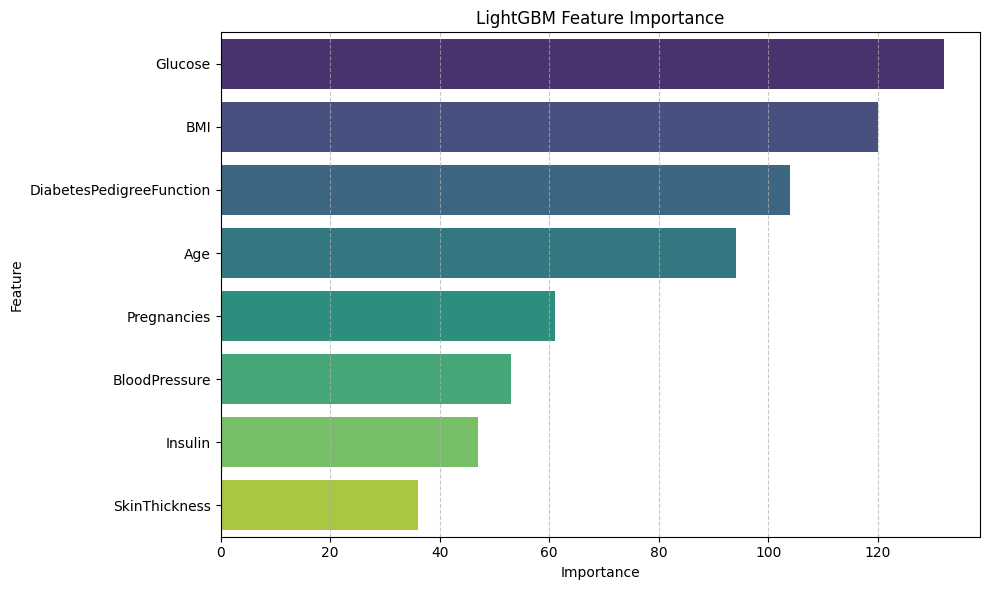

In [4]:
# Get feature importances from the best LightGBM model
feature_importances_lgb = best_lgb_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df_lgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_lgb
})

# Sort the features by importance in descending order
feature_importance_df_lgb = feature_importance_df_lgb.sort_values(by='Importance', ascending=False)

# Display the feature importances
print("\nLightGBM Feature Importances:")
display(feature_importance_df_lgb)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_lgb, palette='viridis')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


SHAP Summary Plot for LightGBM Model:


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


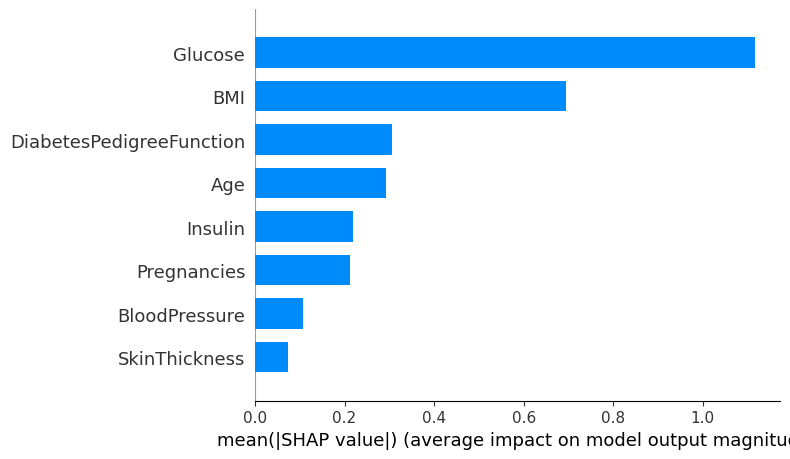

In [5]:
# Install shap library if not already installed
!pip install shap -qq
import shap

# Create a SHAP Tree explainer for the LightGBM model
explainer = shap.TreeExplainer(best_lgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Visualize the SHAP summary plot
print("\nSHAP Summary Plot for LightGBM Model:")
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [6]:
# To show the individual SHAP explanation for the first instance in the test set:
# shap.initjs() # Initialize JavaScript visualization for interactive plots
# shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_test.iloc[0,:])

# For a more aggregated view across classes, especially in multi-class (or binary where shap_values is a list)
# If shap_values is a list (binary classification usually returns a list of two arrays)
# We'll plot for the positive class (class 1)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)